# End-to-End Credit Risk Prediction Model
### ID/X - Partner - Data Science Februari 2026
### Gardasvara Mistortoify

## 1. IMPORT LIBRARIES & LOAD DATA
File loan_data_2007_2014.csv sudah ada di folder direktori yang sama

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
df = pd.read_csv('loan_data_2007_2014.csv', low_memory=False)
print("Data berhasil di-load!")

Data berhasil di-load!


## 2. EDA & DEFINING TARGET VARIABLE (LABELING)
Fokus memprediksi 'Bad Loan'. 
Bad Loan = 1, Good Loan = 0

In [ ]:
def define_target(status):
    if status in ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off', 
                  'Does not meet the credit policy. Status:Default']:
        return 1
    else:
        return 0

df['bad_loan'] = df['loan_status'].apply(define_target)

# Cek proporsi target (Imbalance Check)
print(df['bad_loan'].value_counts(normalize=True))

### 1. Visualisasi Target Variable (Untuk laporan/infografis)

C:\Users\M S I\AppData\Local\Temp\ipykernel_24556\4273715202.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='bad_loan', data=df, palette='viridis')


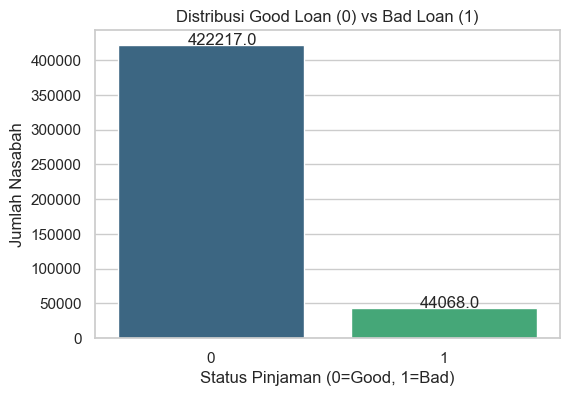

In [ ]:
# Set style untuk visualisasi
sns.set(style="whitegrid")

# 1. Visualisasi Target Variable (Untuk laporan/infografis)
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='bad_loan', data=df, palette='viridis')
plt.title('Distribusi Good Loan (0) vs Bad Loan (1)')
plt.xlabel('Status Pinjaman (0=Good, 1=Bad)')
plt.ylabel('Jumlah Nasabah')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 100))
plt.show()

### 2. Korelasi Fitur Numerik dengan Target (Mencari faktor risiko utama)
Ambil beberapa kolom kunci berdasarkan Data Dictionary

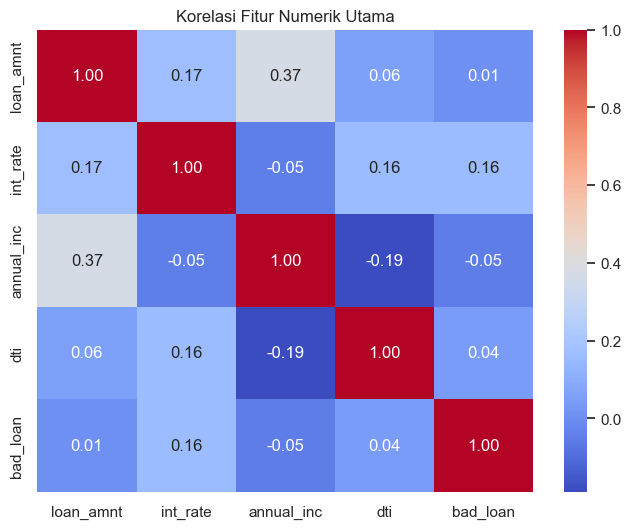

In [ ]:
cols_eda_num = ['loan_amnt', 'int_rate', 'annual_inc', 'dti']
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_eda_num + ['bad_loan']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Fitur Numerik Utama')
plt.show()



1. int_rate (Suku Bunga) - Korelasi Positif Kuat

    Semakin tinggi suku bunga, semakin tinggi risiko gagal bayar. Ini wajar karena peminjam berisiko tinggi memang dikenakan bunga lebih besar sejak awal.

2. dti (Debt-to-Income Ratio) - Korelasi Positif

    Semakin tinggi rasio utang terhadap pendapatan, semakin besar kemungkinan default. Peminjam dengan beban utang yang sudah menumpuk lebih rentan gagal bayar.

3. revol_util (Revolving Line Utilization) - Korelasi Positif

    Penggunaan limit kredit yang mendekati maksimal (misal kartu kredit mentok) mengindikasikan kesulitan likuiditas nasabah.

4. annual_inc (Pendapatan Tahunan) - Korelasi Negatif (Biasanya Lemah)

    Semakin tinggi pendapatan, risiko gagal bayar cenderung turun, namun seringkali korelasinya tidak sekuat int_rate.

### 3. Analisis Bivariate: Grade vs Bad Loan (Apakah Grade rendah lebih sering gagal bayar?)

C:\Users\M S I\AppData\Local\Temp\ipykernel_24556\3226137459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='grade', y='bad_loan', data=df, order=sorted_grades, palette='coolwarm', errorbar=None)


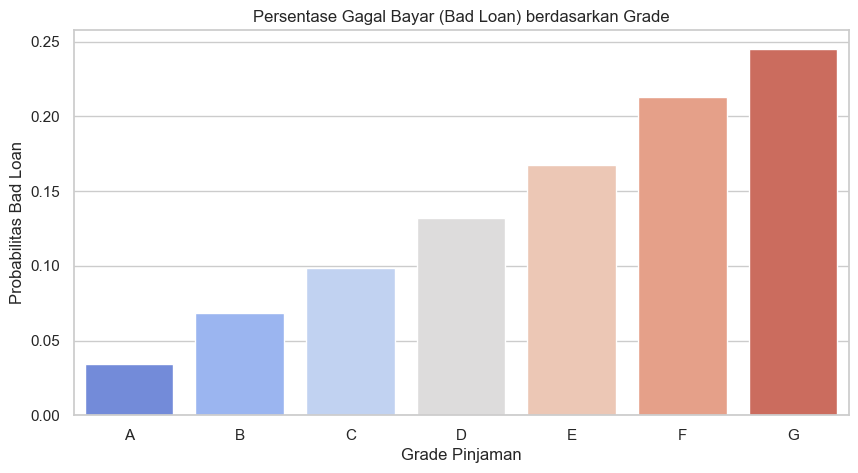

In [7]:
plt.figure(figsize=(10, 5))
sorted_grades = sorted(df['grade'].unique())
sns.barplot(x='grade', y='bad_loan', data=df, order=sorted_grades, palette='coolwarm', errorbar=None)
plt.title('Persentase Gagal Bayar (Bad Loan) berdasarkan Grade')
plt.ylabel('Probabilitas Bad Loan')
plt.xlabel('Grade Pinjaman')
plt.show()

Insight: Grafik naik dari A ke G, berarti Grade berfungsi dengan baik (Riskier loans have higher grades).

### 4. Analisis Bivariate: Term (Tenor) vs Bad Loan

C:\Users\M S I\AppData\Local\Temp\ipykernel_24556\2608489860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='term', y='bad_loan', data=df, palette='muted', errorbar=None)


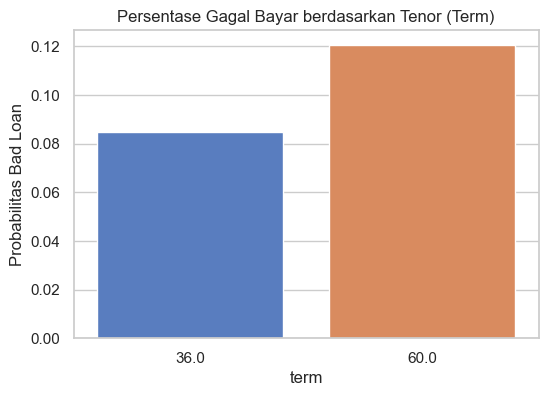

In [8]:
plt.figure(figsize=(6, 4))
sns.barplot(x='term', y='bad_loan', data=df, palette='muted', errorbar=None)
plt.title('Persentase Gagal Bayar berdasarkan Tenor (Term)')
plt.ylabel('Probabilitas Bad Loan')
plt.show()

Insight: Tenor panjang (60 bulan) memiliki risiko lebih tinggi daripada 36 bulan.

## 3. DATA CLEANING & FEATURE SELECTION
1. Membuang Sampah (Drop Useless): Menghapus kolom seperti ID, URL, dan Deskripsi yang tidak memiliki pola statistik untuk prediksi.

2. Mencegah "Kecurangan" (Drop Leakage): Menghapus kolom "masa depan" (seperti total pembayaran yang sudah diterima). Jika kolom ini ada, model akan tahu jawabannya (apakah lunas/gagal) sebelum memprediksi, yang membuat model tidak valid dipakai untuk peminjam baru.

3. Efisiensi Data (Drop High Missing Value): Kolom yang isinya lebih dari 50% kosong dibuang karena terlalu sedikit informasinya untuk dipelajari.

4. Konversi Teks ke Angka:

    - term: Dari "36 months" menjadi angka 36.0.

    - emp_length: Dari "10+ years" menjadi angka 10.0. Ini penting agar mesin bisa menghitungnya secara matematis.

In [ ]:
# A. Drop Kolom Unik/Tidak Berguna
cols_to_drop = ['id', 'member_id', 'url', 'desc', 'policy_code', 'zip_code', 'addr_state', 'title', 'emp_title']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# B. Drop Kolom Data Leakage
leakage_cols = ['recoveries', 'collection_recovery_fee', 'total_rec_prncp', 'total_rec_int', 
                'total_rec_late_fee', 'total_pymnt', 'total_pymnt_inv', 'last_pymnt_d', 
                'last_pymnt_amnt', 'next_pymnt_d', 'out_prncp', 'out_prncp_inv']
df.drop(columns=leakage_cols, inplace=True, errors='ignore')

# C. Drop Kolom dengan Missing Value > 50%
threshold = len(df) * 0.5
df.dropna(thresh=threshold, axis=1, inplace=True)

# D. Feature Engineering Sederhana
# Membersihkan 'term' (contoh: " 36 months" -> 36)
df['term'] = df['term'].astype(str).str.replace(' months', '').astype(float)

# Membersihkan 'emp_length' (contoh: "10+ years" -> 10)
df['emp_length'] = df['emp_length'].astype(str).str.replace(r'\D', '', regex=True)
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce') # Ubah ke angka, yang error jadi NaN
df['emp_length'] = df['emp_length'].fillna(0) # Fill NA dengan 0 tanpa inplace=True

print("Step 3 Selesai: Data Cleaning Berhasil.")

Step 3 Selesai: Data Cleaning Berhasil.


#### VERIFIKASI HASIL DATA CLEANING & FEATURE SELECTION

In [ ]:
print("1. Cek Ukuran Data (Baris, Kolom):")
print(df.shape)

print("\n2. Cek Tipe Data 'term' dan 'emp_length':")
print(df[['term', 'emp_length']].dtypes)

print("\n3. Cek Sampel Data 'term' dan 'emp_length':")
print(df[['term', 'emp_length']].head())

print("\n4. Cek Apakah Kolom Leakage Masih Ada?")
leakage_check = 'recoveries' in df.columns
print(f"Kolom 'recoveries' ada di dataframe? {leakage_check}")

1. Cek Ukuran Data (Baris, Kolom):
(466285, 35)

2. Cek Tipe Data 'term' dan 'emp_length':
term          float64
emp_length      int64
dtype: object

3. Cek Sampel Data 'term' dan 'emp_length':
   term  emp_length
0  36.0         100
1  60.0          10
2  36.0         100
3  36.0         100
4  60.0          10

4. Cek Apakah Kolom Leakage Masih Ada?
Kolom 'recoveries' ada di dataframe? False


## 4. PREROCESSING & FEATURE ENGINEERING 
1. Menambal Data Bolong (Imputation):

    - Model Machine Learning (seperti Logistic Regression) matematika-nya akan error jika bertemu nilai kosong (NaN).

    - Solusi: Isi kekosongan tersebut. Untuk kolom angka, isi dengan nilai tengah (median). Untuk kolom kategori/teks, isi dengan data yang paling sering muncul (mode).

2. Membuang Fitur yang Belum Perlu :

    - Membuang kolom tanggal (issue_d, earliest_cr_line) karena model tidak bisa langsung membaca format tanggal "Jan-2010".

3. One-Hot Encoding :

    - Model tidak mengerti teks seperti "RENT", "OWN", atau "MORTGAGE".

    - Solusi: Ubah menjadi angka "1" dan "0".

    - Contoh: Kolom home_ownership akan pecah menjadi home_ownership_RENT, home_ownership_OWN, dll. Jika nasabah menyewa rumah, maka home_ownership_RENT bernilai 1, sisanya 0.

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns


for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

# Membuang 'loan_status' karena sudah ada 'bad_loan'
# Kita juga membuang 'issue_d' dkk karena format tanggal sulit diproses model sederhana
features = df.drop(['bad_loan', 'loan_status', 'issue_d', 'earliest_cr_line', 'last_credit_pull_d'], axis=1, errors='ignore')
target = df['bad_loan']

# One-Hot Encoding
features = pd.get_dummies(features, drop_first=True)

print("Step 4 Selesai: Preprocessing Berhasil.")

Step 4 Selesai: Preprocessing Berhasil.


### VERIFIKASI HASIL STEP 4

In [ ]:
print("1. Cek Sisa Missing Values:")
total_nan = features.isnull().sum().sum()
print(f"Jumlah nilai kosong di dataset: {total_nan}")

print("\n2. Cek Tipe Data (Harus Angka Semua):")
non_numeric = features.select_dtypes(include=['object']).columns
print(f"Jumlah kolom bertipe object/teks: {len(non_numeric)}")

print("\n3. Cek Jumlah Kolom Setelah Encoding:")
print(f"Shape awal (sebelum encoding): {df.shape}")
print(f"Shape akhir (features siap training): {features.shape}")

print("\n4. Data Siap Pakai (5 Baris Pertama):")
print(features.head())

1. Cek Sisa Missing Values:
Jumlah nilai kosong di dataset: 0

2. Cek Tipe Data (Harus Angka Semua):
Jumlah kolom bertipe object/teks: 0

3. Cek Jumlah Kolom Setelah Encoding:
Shape awal (sebelum encoding): (466285, 35)
Shape akhir (features siap training): (466285, 84)

4. Intip Data Siap Pakai (5 Baris Pertama):
   Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv  term  int_rate  \
0           0       5000         5000           4975.0  36.0     10.65   
1           1       2500         2500           2500.0  60.0     15.27   
2           2       2400         2400           2400.0  36.0     15.96   
3           3      10000        10000          10000.0  36.0     13.49   
4           4       3000         3000           3000.0  60.0     12.69   

   installment  emp_length  annual_inc    dti  ...  purpose_house  \
0       162.87         100     24000.0  27.65  ...          False   
1        59.83          10     30000.0   1.00  ...          False   
2        84.33         100     1

## 5. MODELING (TRAIN-TEST SPLIT & TRAINING)
Pada tahap ini, dataset dibagi menjadi dua bagian: Training Set (80%) untuk melatih model dan Test Set (20%) untuk menguji performa model. Karena rentang nilai antar fitur berbeda (misalnya loan_amnt puluhan ribu vs dti puluhan), fitur-fitur dinormalisasi menggunakan StandardScaler agar algoritma dapat bekerja optimal. Algoritma yang digunakan adalah Logistic Regression dengan parameter class_weight='balanced' untuk menangani ketidakseimbangan kelas pada target variabel.

In [17]:
# ==========================================
# 5. MODELING (GRADIENT BOOSTING) - PRO VERSION
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

# 1. Split Data (Sama seperti sebelumnya)
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.2, 
    random_state=42, 
    stratify=target
)

# 2. Scaling (Opsional untuk Boosting, tapi baik untuk konsistensi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Training Model Gradient Boosting
# n_estimators=100: Membuat 100 pohon koreksi bertahap
# learning_rate=0.1: Seberapa kuat setiap pohon mengoreksi error (makin kecil makin teliti tapi lambat)
# max_depth=5: Pohonnya tidak terlalu dalam agar tidak overfitting
model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    validation_fraction=0.1, # Gunakan sebagian data train untuk memantau error
    n_iter_no_change=10      # Berhenti jika tidak ada perbaikan (Early Stopping)
)

print("Sedang melatih model Gradient Boosting (Mungkin butuh 1-2 menit)...")
model.fit(X_train_scaled, y_train)

# 4. Prediksi
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Step 5 Selesai: Model Gradient Boosting berhasil dilatih.")

Sedang melatih model Gradient Boosting (Mungkin butuh 1-2 menit)...
Step 5 Selesai: Model Gradient Boosting berhasil dilatih.


## 6. EVALUATION MODEL
1. ROC-AUC Score: Mengukur kemampuan model membedakan antara Good Loan dan Bad Loan. Semakin dekat ke 1, semakin bagus.

2. Recall (untuk kelas 1/Bad Loan): Seberapa banyak Bad Loan yang berhasil ditebak benar oleh model.

3. Confusion Matrix: Tabel untuk melihat detail berapa yang tebakannya benar vs salah.

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     84443
           1       0.40      0.00      0.00      8814

    accuracy                           0.91     93257
   macro avg       0.65      0.50      0.48     93257
weighted avg       0.86      0.91      0.86     93257

ROC-AUC Score: 0.7232


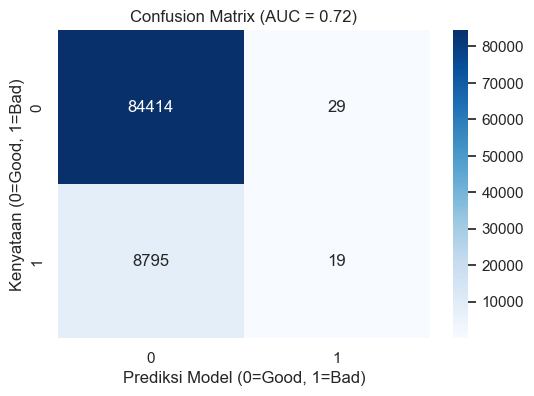

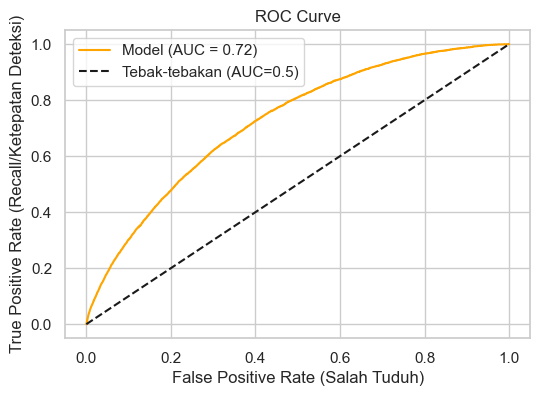

AttributeError: 'GradientBoostingClassifier' object has no attribute 'coef_'

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Tampilkan Angka Statistik (Classification Report)
print("--- Classification Report ---")
# y_test adalah kunci jawaban asli, y_pred adalah jawaban model
print(classification_report(y_test, y_pred))

# 2. Hitung Skor ROC-AUC
# Menggunakan y_pred_proba (probabilitas) bukan y_pred (kelas bulat)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
# Membuat heatmap: Sumbu Y adalah data Asli, Sumbu X adalah Prediksi
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (AUC = {auc_score:.2f})')
plt.xlabel('Prediksi Model (0=Good, 1=Bad)')
plt.ylabel('Kenyataan (0=Good, 1=Bad)')
plt.show()

# 4. Visualisasi ROC Curve
# Kurva ini menunjukkan trade-off antara menangkap Bad Loan vs salah tuduh Good Loan
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Model (AUC = {auc_score:.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', label='Tebak-tebakan (AUC=0.5)') # Garis diagonal
plt.xlabel('False Positive Rate (Salah Tuduh)')
plt.ylabel('True Positive Rate (Recall/Ketepatan Deteksi)')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 5. Feature Importance (Faktor Apa yang Paling Berpengaruh?)
# Mengambil koefisien dari model Logistic Regression
coeffs = pd.DataFrame({
    'Feature': features.columns,
    'Weight': model.coef_[0]
})

# Mengurutkan berdasarkan nilai absolut terbesar (pengaruh terkuat)
coeffs['Abs_Weight'] = coeffs['Weight'].abs()
top_features = coeffs.sort_values(by='Abs_Weight', ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x='Weight', y='Feature', data=top_features, palette='coolwarm')
plt.title('Top 10 Fitur Paling Berpengaruh (Feature Importance)')
plt.xlabel('Bobot Koefisien (Positif = Risiko Naik, Negatif = Risiko Turun)')
plt.show()